In [1]:
# CELL 1 - Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.append('../src')
from data_loader import load_data
from imputation import impute_categorical
from outlier_handler import outlier_summary
from feature_engineering import add_price_per_item, add_date_features, add_order_value_category, add_has_coupon

In [2]:
# CELL 2 - Rebuild full pipeline from scratch (chain all phases)
df = load_data('../data/raw/Dataset for Data Analytics.xlsx')
df = impute_categorical(df, 'CouponCode', strategy='unknown', fill_value='NoCoupon')
df = add_price_per_item(df)
df = add_date_features(df)
df = add_order_value_category(df)
df = add_has_coupon(df)
df = df.drop(columns=['order_quarter'])   # dropped due to multicollinearity with order_month
df.head()

Shape: 1200 rows, 14 columns
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,price_per_item,order_month,order_day_of_week,order_value_category,has_coupon
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,407.585714,1,Wednesday,High,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,100.900000,8,Friday,Low,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,344.175000,2,Tuesday,High,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,54.638000,10,Sunday,Low,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,313.005000,5,Thursday,High,1


In [3]:
# CELL 3 - Final describe/info
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,price_per_item,order_month,has_coupon
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,207.721767,5.995000,0.742500
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,1.898333,1.000000,0.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,83.053214,3.000000,0.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,172.681250,6.000000,1.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,301.199667,9.000000,1.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,697.930000,12.000000,1.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,154.225007,3.344293,0.437439


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               1200 non-null   str           
 1   Date                  1200 non-null   datetime64[us]
 2   CustomerID            1200 non-null   str           
 3   Product               1200 non-null   str           
 4   Quantity              1200 non-null   int64         
 5   UnitPrice             1200 non-null   float64       
 6   ShippingAddress       1200 non-null   str           
 7   PaymentMethod         1200 non-null   str           
 8   OrderStatus           1200 non-null   str           
 9   TrackingNumber        1200 non-null   str           
 10  ItemsInCart           1200 non-null   int64         
 11  CouponCode            1200 non-null   str           
 12  ReferralSource        1200 non-null   str           
 13  TotalPrice            1200 no

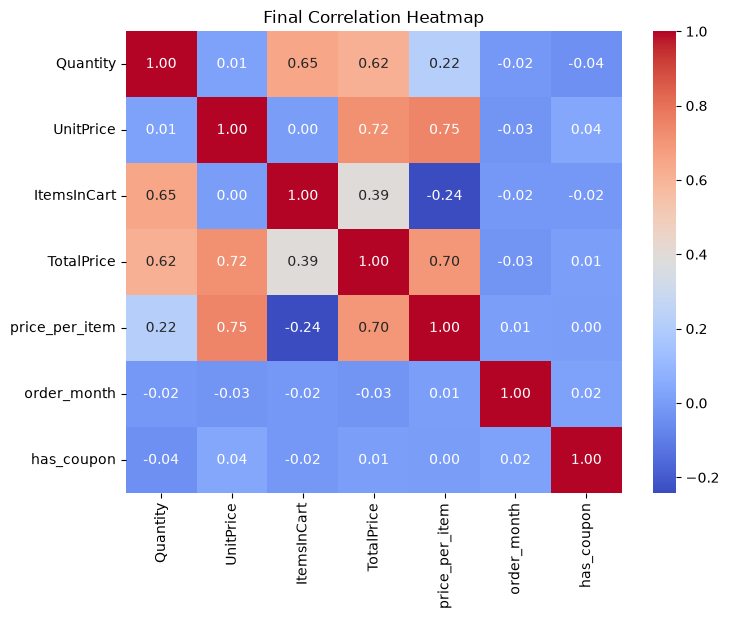

In [5]:
# CELL 4 - Final correlation heatmap
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'price_per_item', 'order_month', 'has_coupon']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Final Correlation Heatmap')
plt.show()

In [6]:
# CELL 5 - Before vs after missing values comparison
raw_df = load_data('../data/raw/Dataset for Data Analytics.xlsx')
missing_compare = pd.DataFrame({
    'before': raw_df.isnull().sum(),
    'after': df.isnull().sum(),
})
missing_compare.loc['TOTAL'] = missing_compare.sum()
missing_compare

Shape: 1200 rows, 14 columns
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


,before,after
CouponCode,309.0,0.0
CustomerID,0.0,0.0
Date,0.0,0.0
ItemsInCart,0.0,0.0
OrderID,0.0,0.0
OrderStatus,0.0,0.0
PaymentMethod,0.0,0.0
Product,0.0,0.0
Quantity,0.0,0.0
ReferralSource,0.0,0.0


In [7]:
# CELL 6 - Before vs after outlier comparison (TotalPrice)
outlier_summary(df, ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'])

,outlier_count,outlier_pct
column,,
Quantity,0,0.00
UnitPrice,0,0.00
ItemsInCart,0,0.00
TotalPrice,8,0.67


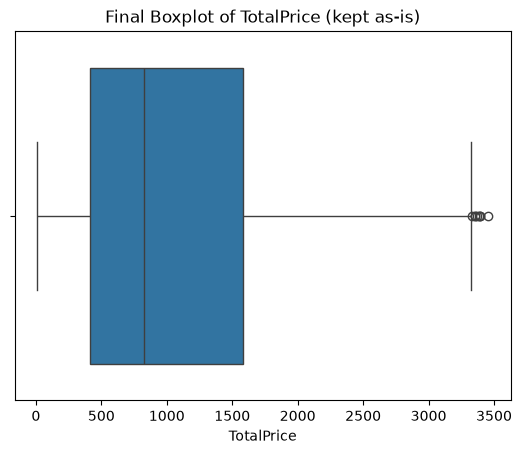

In [8]:
# TotalPrice has 8 outliers (0.67%) - kept, no treatment (documented in eda_summary.md)
plt.figure()
sns.boxplot(x=df['TotalPrice'])
plt.title('Final Boxplot of TotalPrice (kept as-is)')
plt.show()

In [9]:
# CELL 7 - Save final cleaned dataset
df.to_csv('../data/processed/dataset_cleaned.csv', index=False)
print('Saved:', df.shape)

Saved: (1200, 19)


## CELL 8 - Final Summary

- **Rows/columns:** Started with 1200 rows x 14 columns; final cleaned dataset is **1200 rows x 19 columns** (`dataset_cleaned.csv`)
- **Missing handled:** `CouponCode` NaN (309 rows, ~25.75%) imputed to `'NoCoupon'` (strategy='unknown'); all columns now have 0 missing values
- **Outliers handled:** Only `TotalPrice` had outliers (8 counts, 0.67%) - **kept, no treatment** to preserve genuine high-value orders
- **Features added:**
  - `price_per_item` = TotalPrice / ItemsInCart
  - `order_month`, `order_day_of_week` (from Date)
  - `order_value_category` = Low / Medium / High bins of TotalPrice
  - `has_coupon` = 1 if coupon used, else 0
  - `order_quarter` was dropped (multicollinear with `order_month`)
- **Final columns:** 14 original + 5 new (order_quarter excluded)